In [1]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
import os
from data_loader import DataLoader
from gtsam.symbol_shorthand import B, V, X
from gtsam import NavState, Pose3, Rot3, Point3
from gtsam.utils.plot import plot_pose3, set_axes_equal
from mpl_toolkits.mplot3d import Axes3D
from typing import Optional, List
from functools import partial
# %matplotlib qt

Set the dataset path

In [2]:
DATA_DIR = "./full_dataset"
DataLoader.get_dir(DATA_DIR)

Data directory set to: ./full_dataset


In [3]:
# read sensor data
imu_file =  "imu_adis_ros.csv"
dvl_file =  "dvl_linkquest.csv"
depth_file =  "depth_sensor.csv"
odom_file = "odometry.csv"

imu = DataLoader.read_imu(imu_file)
dvl = DataLoader.read_dvl(dvl_file)
depth = DataLoader.read_depth(depth_file)
odom = DataLoader.read_odom(odom_file)

# print(imu)

Time synchronization -> choose imu time to be the baseline

In [4]:
# time synchronization
start_time = imu['time'][0]

# print(f"Start time: {start_time}")
# offeset all timestamps to start from zero
imu['time'] -= start_time
dvl['time'] -= start_time
depth['time'] -= start_time
odom['time'] -= start_time

# show new time
print(f"New start time: {imu['time'][0]}")
print(f"New end time: {imu['time'][-1]}")

# convert nanoseconds to seconds
imu['time'] /= 1e9
dvl['time'] /= 1e9
depth['time'] /= 1e9
odom['time'] /= 1e9

# print
print(f"IMU time range: {imu['time'][0]} to {imu['time'][-1]}")

New start time: 0.0
New end time: 1955073564672.0
IMU time range: 0.0 to 1955.073564672


Set initial values (biases and noises) for preintegrated imu

In [5]:
# state initialization
# biases
accBias = np.array([0.067, 0.115, 0.32])
gyroBias = np.array([0.067, 0.115, 0.32])
bias = gtsam.imuBias.ConstantBias(accBias, gyroBias)

# set gravity
pim_params = gtsam.PreintegrationParams.MakeSharedU(9.81)

# Some arbitrary noise sigmas
gyro_sigma = 1e-3
accel_sigma = 1e-3
I_3x3 = np.eye(3)
pim_params.setGyroscopeCovariance(gyro_sigma**2 * I_3x3)
pim_params.setAccelerometerCovariance(accel_sigma**2 * I_3x3)
pim_params.setIntegrationCovariance(1e-3**2 * I_3x3)

# preintegrate imu measurements
pim = gtsam.PreintegratedImuMeasurements(pim_params, bias)

# Noise models for factors
priorNoise = gtsam.noiseModel.Isotropic.Sigma(6, 0.1)
velNoise = gtsam.noiseModel.Isotropic.Sigma(3, 0.1)

In [6]:
def get_initial_state_from_data(query_time, odom_data, dvl_data):
    """
    Interpolates Odometry and DVL data to get a robust initial estimate 
    for Pose and Velocity at a specific time.
    """
    # 1. Find nearest index in Odometry for Position/Orientation
    # (Using searchsorted is faster than argmin for sorted time)
    idx = np.searchsorted(odom_data['time'], query_time)
    if idx == 0: idx = 1
    if idx >= len(odom_data['time']): idx = len(odom_data['time']) - 1
    
    # Linear Interpolation factor
    t0 = odom_data['time'][idx-1]
    t1 = odom_data['time'][idx]
    ratio = 0.0
    if t1 > t0:
        ratio = (query_time - t0) / (t1 - t0)
        
    # Interpolate Position
    pos0 = np.array([odom_data['x'][idx-1], odom_data['y'][idx-1], odom_data['z'][idx-1]])
    pos1 = np.array([odom_data['x'][idx], odom_data['y'][idx], odom_data['z'][idx]])
    pos_interp = pos0 + ratio * (pos1 - pos0)
    
    # Get Rotation (Nearest neighbor is sufficient for initialization, or SLERP if precise)
    # Using nearest for stability
    q_idx = idx if ratio > 0.5 else idx - 1
    rot = gtsam.Rot3.Quaternion(
        odom_data['qw'][q_idx],
        odom_data['qx'][q_idx],
        odom_data['qy'][q_idx],
        odom_data['qz'][q_idx]
    )
    
    pose_est = gtsam.Pose3(rot, gtsam.Point3(*pos_interp))
    
    # 2. Get Velocity from DVL
    # DVL measures body velocity. NavState needs World velocity.
    # V_world = R_body_to_world * V_body
    v_idx = np.searchsorted(dvl_data['time'], query_time)
    if v_idx >= len(dvl_data['time']): v_idx = len(dvl_data['time']) - 1
    
    # Nearest DVL reading
    v_body = np.array([
        dvl_data['vx'][v_idx], 
        dvl_data['vy'][v_idx], 
        dvl_data['vz'][v_idx]
    ])
    
    vel_world_est = rot.rotate(gtsam.Point3(*v_body))
    
    return pose_est, vel_world_est

Main loop for preintegrating imu

In [7]:
def main_loop(graph, initial):
    # add prior initial node from odometry
    init_pose = Pose3(
        Rot3.Quaternion(
            odom['qw'][0],
            odom['qx'][0],
            odom['qy'][0],
            odom['qz'][0],
        ),
        Point3(
            odom['x'][0],
            odom['y'][0],
            odom['z'][0],
        )
    )

    init_vel = Point3(0.0, 0.0, 0.0)

    init_state = NavState(init_pose, init_vel)

    # add initial graph
    graph.push_back(gtsam.PriorFactorPose3(X(0), init_state.pose(), priorNoise)) # position
    graph.push_back(gtsam.PriorFactorVector(V(0), init_state.velocity(), velNoise)) # velocity

    # add initial values
    initial.insert(X(0), init_state.pose())
    initial.insert(V(0), init_state.velocity())
    # initial.insert(B(0), bias)
    # enumerate imu data
    # set last time
    last_time = imu['time'][0]
    # set initial state
    # prev_state = initial
    prev_state = init_state

    key_index = 0

    for i in range(1, len(imu['time'])):
    # for i in range(1, 100):
        # get measurement data at index i
        dt = imu['time'][i] - imu['time'][i - 1]
        # print(f"dt: {dt}")
        measured_acc = np.array([
            imu['ax'][i],
            imu['ay'][i],
            imu['az'][i],
        ])
        # print(f"measured_acc: {measured_acc}")
        measured_omg = np.array([
            imu['omega_x'][i],
            imu['omega_y'][i],
            imu['omega_z'][i],
        ])
        # print(f"measured_omg: {measured_omg}")

        # integrate measurement
        pim.integrateMeasurement(measured_acc, measured_omg, dt)

        freq = 3.0 # Hz (DVL freq)
        threshold = 1.0 / freq
        current_time = imu['time'][i]
        if current_time - last_time  >= threshold:
            # Create IMU factor every threshold seconds
            factor = gtsam.ImuFactor(X(key_index), V(key_index), X(key_index + 1), V(key_index + 1), B(0), pim)
            graph.push_back(factor)

            # get nav state
            # actual_state = pim.predict(prev_state, bias)
            pose_est, vel_est = get_initial_state_from_data(current_time, odom, dvl)

            # insert initial estimate
            initial.insert(X(key_index + 1), pose_est)
            initial.insert(V(key_index + 1), vel_est)
            key_index += 1
            print(f"Inserted key index: {key_index}")
            
            pim.resetIntegration()
            # prev_state = actual_state # for next time

            last_time = current_time # for next time
        
        

Create imu graph and run imu preintegration

In [8]:
graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()
initial.insert(B(0), bias)
main_loop(graph, initial)

Inserted key index: 1
Inserted key index: 2
Inserted key index: 3
Inserted key index: 4
Inserted key index: 5
Inserted key index: 6
Inserted key index: 7
Inserted key index: 8
Inserted key index: 9
Inserted key index: 10
Inserted key index: 11
Inserted key index: 12
Inserted key index: 13
Inserted key index: 14
Inserted key index: 15
Inserted key index: 16
Inserted key index: 17
Inserted key index: 18
Inserted key index: 19
Inserted key index: 20
Inserted key index: 21
Inserted key index: 22
Inserted key index: 23
Inserted key index: 24
Inserted key index: 25
Inserted key index: 26
Inserted key index: 27
Inserted key index: 28
Inserted key index: 29
Inserted key index: 30
Inserted key index: 31
Inserted key index: 32
Inserted key index: 33
Inserted key index: 34
Inserted key index: 35
Inserted key index: 36
Inserted key index: 37
Inserted key index: 38
Inserted key index: 39
Inserted key index: 40
Inserted key index: 41
Inserted key index: 42
Inserted key index: 43
Inserted key index: 

Some plottings

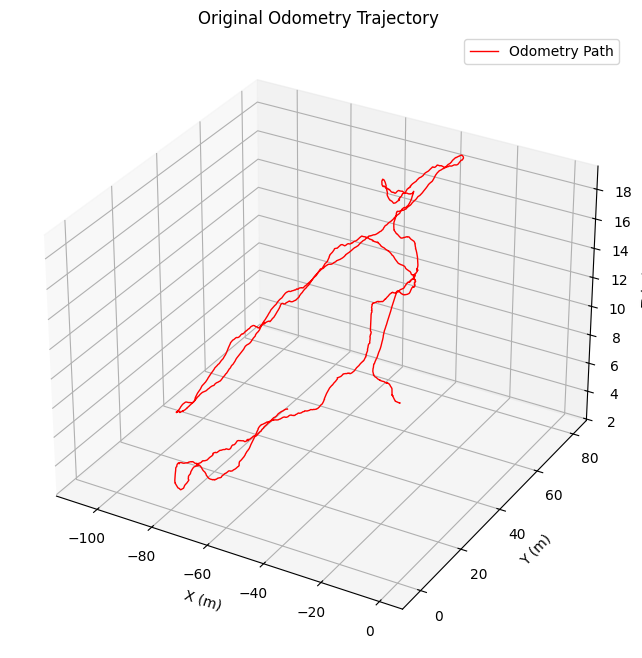

In [9]:
# plot original imu trajectory
def plot_ori_odom():
    xs, ys, zs = [], [], []
    for i in range(len(imu['time'])):
        xs.append(odom['x'][i])
        ys.append(odom['y'][i])
        zs.append(odom['z'][i])
    
    fig = plt.figure(2, figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(xs, ys, zs, '-r', linewidth=1, label="Odometry Path")
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title("Original Odometry Trajectory")
    ax.legend()
    plt.show()

plot_ori_odom()

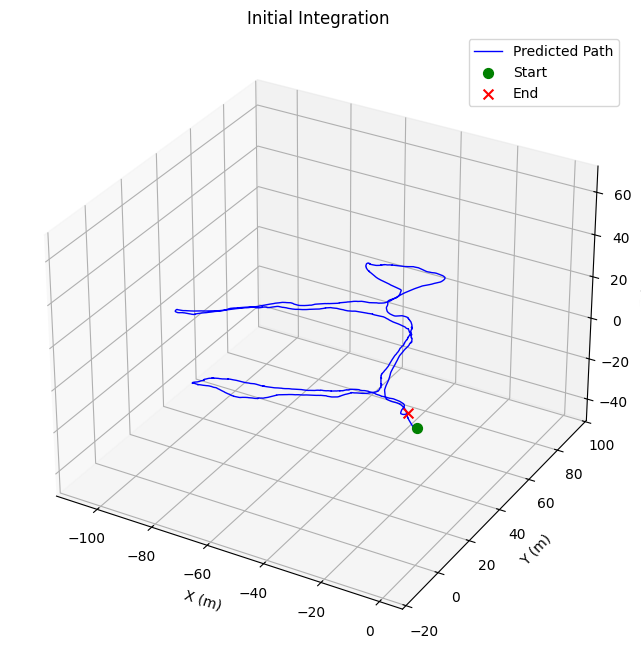

In [10]:
def plot_trajectory_fast(values: gtsam.Values, 
                         title: str = "Trajectory", 
                         fignum: int = 1, 
                         show: bool = True):
    # 1. Create/Get the figure
    fig = plt.figure(fignum, figsize=(10, 8))
    
    # 2. CLEAR the figure to remove any existing 2D axes
    fig.clf() 
    
    # 3. Explicitly add a 3D subplot
    ax = fig.add_subplot(111, projection='3d')
    
    xs, ys, zs = [], [], []
    i = 0
    
    # Extract data
    while values.exists(X(i)):
        pose = values.atPose3(X(i))
        p = pose.translation()
        
        xs.append(p[0])
        ys.append(p[1])
        zs.append(p[2])
        i += 1
    
    if len(xs) == 0:
        print("No poses found!")
        return

    # Plot the path line
    ax.plot(xs, ys, zs, '-b', linewidth=1, label="Predicted Path")
    
    # Mark Start (Green) and End (Red)
    # Note: On a 3D axis, scatter accepts (x, y, z)
    ax.scatter(xs[0], ys[0], zs[0], c='g', marker='o', s=50, label="Start")
    ax.scatter(xs[-1], ys[-1], zs[-1], c='r', marker='x', s=50, label="End")

    # Labels and Title
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title(title)
    ax.legend()
    
    # Equal Aspect Ratio (Try/Except in case utils are missing)
    try:
        gtsam.utils.plot.set_axes_equal(fignum)
    except:
        pass
        
    if show:
        plt.show()

# Run it
plot_trajectory_fast(initial, title="Initial Integration", fignum=1)

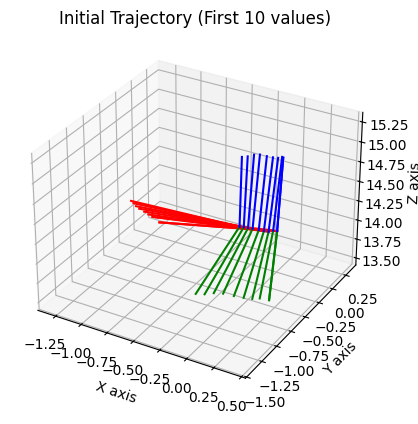

In [11]:
def plot_trajectory(values: gtsam.Values,
                    title: str = "Estimated Trajectory",
                    fignum: int = 1,
                    limit: int = 100, # <--- Limit parameter
                    show: bool = False):
    i = 0
    # Run while key exists AND i is less than limit
    while values.exists(X(i)) and i < limit:
        pose_i = values.atPose3(X(i))
        plot_pose3(fignum, pose_i, 1)
        i += 1
        
    plt.title(f"{title} (First {i} values)")

    gtsam.utils.plot.set_axes_equal(fignum)

    plt.ioff()

    if show:
        plt.show()

# Usage: Plot only the first 100 values
plot_trajectory(initial, title="Initial Trajectory", fignum=7, limit=10, show=True)


Initial error: 1.44973e+09, values: 9985
iter      cost      cost_change    lambda  success iter_time
   0  2.06402e+11       -2e+11      1e-05      1       0.09
iter      cost      cost_change    lambda  success iter_time
   0      8.7e+10     -8.6e+10     0.0001      1       0.08
iter      cost      cost_change    lambda  success iter_time
   0        4e+10     -3.9e+10      0.001      1       0.07
iter      cost      cost_change    lambda  success iter_time
   0      1.2e+10     -1.1e+10       0.01      1       0.07
iter      cost      cost_change    lambda  success iter_time
   0      5.5e+09     -4.1e+09        0.1      1       0.08
iter      cost      cost_change    lambda  success iter_time
   0      3.4e+09     -1.9e+09          1      1       0.08
iter      cost      cost_change    lambda  success iter_time
   0      1.8e+09     -3.2e+08         10      1       0.08
iter      cost      cost_change    lambda  success iter_time
   0      5.8e+08      8.7e+08      1e+02      1   

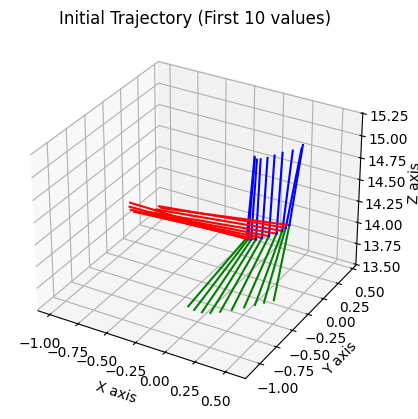

In [ ]:
# optimize the graph    
lm_params = gtsam.LevenbergMarquardtParams()
lm_params.setVerbosityLM("SUMMARY")
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial, lm_params)
result = optimizer.optimize()


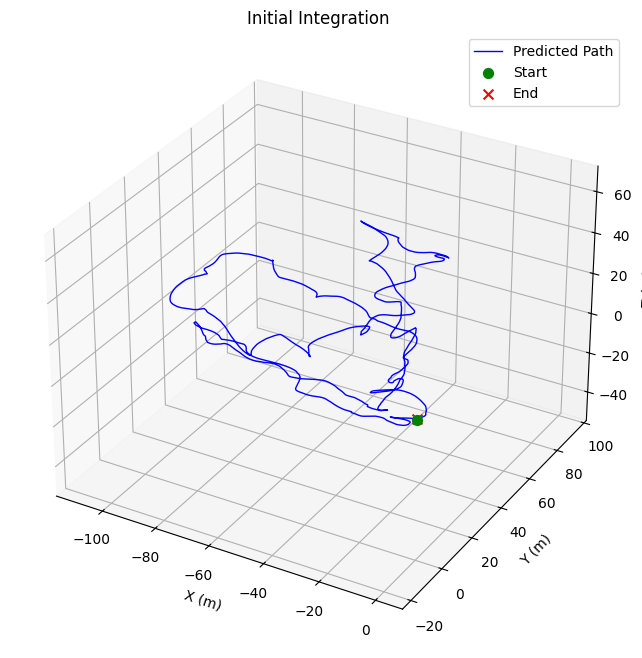

In [ ]:
plot_trajectory_fast(result, title="Initial Integration", fignum=1)

As you can see, the error grows very fast. So, the position should be corrected by adding the velocity.

Add noise model for DVL and depth sensor

In [ ]:
# # arbitary noise models for depth and dvl
depth_noise_model = gtsam.noiseModel.Isotropic.Sigma(1, 0.001) # 0.1 cm stddev
dvl_noise_model = gtsam.noiseModel.Isotropic.Sigma(3, 0.01) # 1 cm/s stddev

# # create error definition for depth and velocity
# def depth_error(
#         measurement: np.ndarray,
#         this: gtsam.CustomFactor,
#         values: gtsam.Values,
#         jacobians: Optional[List[np.ndarray]],
#     ) -> float:
#         """
#         Calculate the error betwen the depth sensor and the depth prediction
#         """
#         # Measurement is >0, meaning that it should be inverted
#         assert measurement <= 0, "Measurement should be negative"
#         key = this.keys()[0]
#         estimate = values.atPose3(key)
#         depth = estimate.z()
#         error = measurement - depth

#         print(f"Depth Measurement: {measurement}, Estimated Depth: {depth}, Depth Error: {error}")
#         if jacobians is not None:
#             # The state is a Pose3 (6DOF). Tangent space is [Rotation(3), Translation(3)].
#             # We need the derivative of World_Z with respect to a body-frame perturbation.
#             # equation: pos_world = pos_current + R * perturbation_translation
#             # dz_world = R_row3 * perturbation_translation
            
#             H = np.zeros((1, 6))
#             R = estimate.rotation().matrix()
            
#             # The derivative wrt rotation is 0 (for a point sensor at the origin)
#             # The derivative wrt translation is the 3rd row of the rotation matrix
#             # Columns 0-2 are rotation, 3-5 are translation
#             H[0, 3] = R[2, 0]
#             H[0, 4] = R[2, 1]
#             H[0, 5] = R[2, 2]
            
#             jacobians[0] = H
#         return error

# def velocity_error(
#         measurement: np.ndarray,
#         this: gtsam.CustomFactor,
#         values: gtsam.Values,
#         jacobians: Optional[List[np.ndarray]],
#     ) -> float:
#         """
#         Calculate the error betwen the velocity prediction and the velocity measurement
#         """
#         key_pose = this.keys()[0]
#         key_vel = this.keys()[1]
#         pose_estimate = values.atPose3(key_pose)
#         vel_estimate = values.atPoint3(key_vel)

#         rot_mat = pose_estimate.rotation().matrix()
#         vx = vel_estimate[0]
#         vy = vel_estimate[1]
#         vz = vel_estimate[2]
#         v = np.array([vx, vy, vz]).reshape((3, 1))

#         meas_t = measurement.reshape((3, 1))
#         meas_world = rot_mat @ meas_t


#         error = meas_world - v
#         error = np.array(error).reshape((3,1))

#         # print(f"Rotation Matrix:\n{rot_mat}")
#         # print(f"Velocity Measurement (body frame): {meas_world}")
#         # print(f"Velocity Estimate (world frame): {v}")
#         # print(f"Velocity Error: {error}")
        
#         if jacobians is not None:
#             jacobians[0] = rot_mat
#         return error

def depth_error(
    measurement: np.ndarray,
    this: gtsam.CustomFactor,
    values: gtsam.Values,
    jacobians: Optional[List[np.ndarray]],
) -> float:
    key = this.keys()[0]
    estimate = values.atPose3(key)
    depth = estimate.z()
    error = np.array([measurement - depth])

    if jacobians is not None:
        # Jacobian w.r.t Pose3 (1x6)
        H = np.zeros((1, 6))
        R = estimate.rotation().matrix()
        # Derivative of Z w.r.t body translation is the 3rd row of Rotation matrix
        H[0, 3] = R[2, 0]
        H[0, 4] = R[2, 1]
        H[0, 5] = R[2, 2]
        jacobians[0] = H
    return error

def velocity_error(
    measurement: np.ndarray,
    this: gtsam.CustomFactor,
    values: gtsam.Values,
    jacobians: Optional[List[np.ndarray]],
) -> float:
    key_pose = this.keys()[0]
    key_vel = this.keys()[1]
    
    pose = values.atPose3(key_pose)
    vel_est = values.atPoint3(key_vel) # Estimated velocity in World Frame
    
    R = pose.rotation().matrix()
    v_meas_body = measurement # Measured velocity in Body Frame
    
    # Transform measurement to world frame to compare with state
    v_meas_world = R @ v_meas_body
    
    error = v_meas_world - vel_est
    
    if jacobians is not None:
        # --- Jacobian w.r.t Pose (X) [3x6] ---
        if jacobians[0] is not None:
            # We need d(Error)/d(Pose). 
            # Pose has 6 params: [Rotation (3), Translation (3)]
            # Translation does not affect velocity rotation, so cols 3-5 are 0.
            # Rotation affects R. d(R*v)/d(theta) = -R * [v]_skew
            
            vx, vy, vz = v_meas_body
            v_skew = np.array([
                [0, -vz, vy],
                [vz, 0, -vx],
                [-vy, vx, 0]
            ])
            
            H_pose = np.zeros((3, 6))
            H_pose[:, 0:3] = -R @ v_skew  # Rotation block (3x3)
            # Translation block (3x3) remains 0
            
            jacobians[0] = H_pose

        # --- Jacobian w.r.t Velocity (V) [3x3] ---
        if jacobians[1] is not None:
            # Error = Constant - V_est
            # d(Error)/d(V_est) = -Identity
            jacobians[1] = -np.eye(3)

    return error

In [ ]:
# modify main loop to add depth and dvl factors

def new_main_loop(graph, initial):
    # add prior initial node from odometry
    init_pose = Pose3(
        Rot3.Quaternion(
            odom['qw'][0],
            odom['qx'][0],
            odom['qy'][0],
            odom['qz'][0],
        ),
        Point3(
            odom['x'][0],
            odom['y'][0],
            odom['z'][0],
        )
    )

    init_vel = Point3(0.0, 0.0, 0.0)

    init_state = NavState(init_pose, init_vel)

    # add initial graph
    graph.push_back(gtsam.PriorFactorPose3(X(0), init_state.pose(), priorNoise)) # position
    graph.push_back(gtsam.PriorFactorVector(V(0), init_state.velocity(), velNoise)) # velocity

    # add initial values
    initial.insert(X(0), init_state.pose())
    initial.insert(V(0), init_state.velocity())
    initial.insert(B(0), bias)
    # enumerate imu data
    # set last time
    last_time = imu['time'][0]
    # set initial state
    # prev_state = initial
    prev_state = init_state

    key_index = 1 # start key index n

    for i in range(1, len(imu['time'])):
    # for i in range(1, 1000):
        # get measurement data at index i
        dt = imu['time'][i] - imu['time'][i - 1]
        # print(f"dt: {dt}")
        measured_acc = np.array([
            imu['ax'][i],
            imu['ay'][i],
            imu['az'][i],
        ])
        # print(f"measured_acc: {measured_acc}")
        measured_omg = np.array([
            imu['omega_x'][i],
            imu['omega_y'][i],
            imu['omega_z'][i],
        ])
        # print(f"measured_omg: {measured_omg}")

        # integrate measurement
        pim.integrateMeasurement(measured_acc, measured_omg, dt)

        freq = 3.0 # Hz (DVL freq)
        threshold = 1.0 / freq
        current_time = imu['time'][i]

        # time thrshold for dvl and depth
        time_threshold = 1e-4
        
        if current_time - last_time  >= threshold:

            ####### Add imu factor #######

            # Create IMU factor every threshold seconds
            factor = gtsam.ImuFactor(X(key_index - 1), V(key_index - 1), X(key_index), V(key_index), B(0), pim)
            graph.add(factor)

            # get nav state
            # actual_state = pim.predict(prev_state, bias)

            ####### Add depth factor #######
            
            # find closet time
            depth_idx = (np.abs(depth['time'] - current_time)).argmin()
            depth_value = -1.0 * depth['depth'][depth_idx]
            depth_time = depth['time'][depth_idx]
            
            if abs(depth_time - current_time) < time_threshold:
                # print(f"Adding depth factor at key index {key_index} with depth value {depth_value} at time {depth_time}")
                depth_factor = gtsam.CustomFactor(
                        depth_noise_model,
                        [X(key_index)],
                        partial(depth_error, np.array([depth_value])),
                    )
                
                graph.add(depth_factor) 
            
            ####### Add DVL factor #######
            # find closet time
            dvl_idx = (np.abs(dvl['time'] - current_time)).argmin()
            dvl_velocity = np.array([
                dvl['vx'][dvl_idx],
                dvl['vy'][dvl_idx],
                dvl['vz'][dvl_idx],
            ])
            dvl_time = dvl['time'][dvl_idx]

            if abs(dvl_time - current_time) < time_threshold:
                print(f"Adding DVL factor at key index {key_index + 1} with velocity {dvl_velocity} at time {dvl_time}")
                dvl_factor = gtsam.CustomFactor(
                        dvl_noise_model,
                        [X(key_index), V(key_index)],
                        partial(velocity_error, dvl_velocity),
                    )
                
                graph.add(dvl_factor)
            
            pim.resetIntegration()
            
            ####### add initial values #######
            # insert initial estimate
            pose_est, vel_est = get_initial_state_from_data(current_time, odom, dvl)

            # insert initial estimate
            initial.insert(X(key_index), pose_est)
            initial.insert(V(key_index), vel_est)
            key_index += 1
            # print(f"Inserted key index: {key_index}")
            
            # prev_state = actual_state # for next time

            last_time = current_time # for next time



        
        

In [ ]:
# current_time = imu['time'][0]
# depth_idx = (np.abs(depth['time'] - current_time)).argmin()

# print(f"Closest depth index: {depth_idx}, time: {depth['time'][depth_idx]}, depth: {depth['depth'][depth_idx]}")

In [ ]:
new_graph = gtsam.NonlinearFactorGraph()
new_initial = gtsam.Values()
new_main_loop(new_graph, new_initial)

Adding DVL factor at key index 3 with velocity [-0.2923 -0.0702 -0.0176] at time 0.779503104
Adding DVL factor at key index 28 with velocity [-0.2648 -0.044   0.0362] at time 10.570777088
Adding DVL factor at key index 59 with velocity [-0.2538  0.0315  0.0042] at time 22.730280448
Adding DVL factor at key index 90 with velocity [-0.3188 -0.0835  0.0378] at time 34.900332544
Adding DVL factor at key index 105 with velocity [-0.3026 -0.0378  0.0403] at time 40.77812096
Adding DVL factor at key index 120 with velocity [-0.3342  0.1654 -0.0477] at time 46.650925312
Adding DVL factor at key index 143 with velocity [-0.3688 -0.0327  0.0232] at time 55.66478848
Adding DVL factor at key index 151 with velocity [-0.0151  0.2195  0.1061] at time 58.80098688
Adding DVL factor at key index 173 with velocity [-0.4015 -0.0926 -0.0145] at time 67.412125184
Adding DVL factor at key index 198 with velocity [-0.2777 -0.0442 -0.0252] at time 77.190623488
Adding DVL factor at key index 216 with velocity 

In [ ]:
# optimize the new graph
lm_params = gtsam.LevenbergMarquardtParams()
lm_params.setVerbosityLM("SUMMARY")
optimizer = gtsam.LevenbergMarquardtOptimizer(new_graph, new_initial, lm_params)
# new_result = optimizer.optimize()

In [ ]:
new_result = optimizer.optimize()

Initial error: 1.8e+11, values: 9985
iter      cost      cost_change    lambda  success iter_time
   0      8.5e+11     -6.8e+11      1e-05      1       0.73
iter      cost      cost_change    lambda  success iter_time
   0        8e+11     -6.3e+11     0.0001      1       0.74
iter      cost      cost_change    lambda  success iter_time
   0      7.4e+11     -5.7e+11      0.001      1       0.73
iter      cost      cost_change    lambda  success iter_time
   0      7.2e+11     -5.4e+11       0.01      1       0.76
iter      cost      cost_change    lambda  success iter_time
   0        7e+11     -5.3e+11        0.1      1       0.73
iter      cost      cost_change    lambda  success iter_time
   0        7e+11     -5.2e+11          1      1       0.75
iter      cost      cost_change    lambda  success iter_time
   0        7e+11     -5.2e+11         10      1       0.69
iter      cost      cost_change    lambda  success iter_time
   0        7e+11     -5.2e+11      1e+02      1       